In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import warnings

warnings.filterwarnings('ignore')

#Data Read
file_path = 'heart_disease_uci.csv'
df = pd.read_csv(file_path, na_values='?')

-----------------------------------------
Data is split and scaled. Ready for model training.
Training set size: 736 samples
Testing set size: 184 samples
-----------------------------------------


--- Training Logistic Regression ---
--- Evaluation for Logistic Regression ---
Accuracy: 0.8207
Precision: 0.8165
Recall: 0.8725
F1-score: 0.8436
AUC: 0.9061


--- Training Decision Tree ---
--- Evaluation for Decision Tree ---
Accuracy: 0.7935
Precision: 0.7909
Recall: 0.8529
F1-score: 0.8208
AUC: 0.7862


--- Training Random Forest ---
--- Evaluation for Random Forest ---
Accuracy: 0.8370
Precision: 0.8333
Recall: 0.8824
F1-score: 0.8571
AUC: 0.9140


--- Training Support Vector Machine (SVM) ---
--- Evaluation for Support Vector Machine (SVM) ---
Accuracy: 0.8424
Precision: 0.8174
Recall: 0.9216
F1-score: 0.8664
AUC: 0.9206




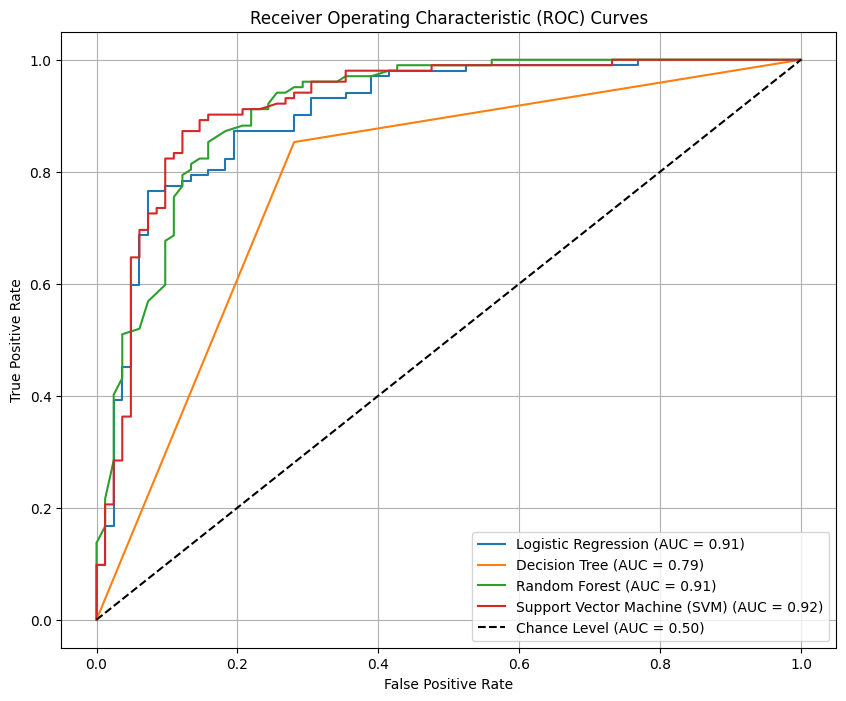

           Model Performance Summary          
                              Accuracy  Precision    Recall  F1-score  \
Logistic Regression           0.820652   0.816514  0.872549  0.843602   
Decision Tree                 0.793478   0.790909  0.852941  0.820755   
Random Forest                 0.836957   0.833333  0.882353  0.857143   
Support Vector Machine (SVM)  0.842391   0.817391  0.921569  0.866359   

                                   AUC  
Logistic Regression           0.906145  
Decision Tree                 0.786227  
Random Forest                 0.913977  
Support Vector Machine (SVM)  0.920612  


In [ ]:
#Handle Missing Values
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            mode_value = df[col].mode()[0]
            df[col].fillna(mode_value, inplace=True)
        else:
            mean_value = df[col].mean()
            df[col].fillna(mean_value, inplace=True)

#Data Encoding
df_processed = df.drop(['id', 'dataset'], axis=1)
df_processed.rename(columns={'num': 'target'}, inplace=True)
df_processed['target'] = (df_processed['target'] > 0).astype(int)
categorical_cols = df_processed.select_dtypes(include=['object']).columns
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

#Separate features (X) and target (y)
X = df_processed.drop('target', axis=1)
y = df_processed['target']

#Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("-----------------------------------------")
print("Data is split and scaled. Ready for model training.")
print(f"Training set size: {X_train_scaled.shape[0]} samples")
print(f"Testing set size: {X_test_scaled.shape[0]} samples")
print("-----------------------------------------")
print("\n")

#Supervised Learning-
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine (SVM)": SVC(random_state=42, probability=True)
}

results = {}
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    print(f"--- Training {model_name} ---")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    #Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[model_name] = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-score": f1}
    
    print(f"--- Evaluation for {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    #Calculate ROC curve and AUC
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    results[model_name]['AUC'] = roc_auc
    
    #Plot ROC curve
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    print(f"AUC: {roc_auc:.4f}")
    print("\n")

#Plotting the ROC Curve
plt.plot([0, 1], [0, 1], 'k--', label='Chance Level (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#Final Results Summary
print("=========================================")
print("           Model Performance Summary          ")
print("=========================================")
results_df = pd.DataFrame(results).T
print(results_df)
print("=========================================")

